# ISRU Scratchpad

This is a scratchpad notebook to be used during development of the ISRU environment.

In [ ]:
%reload_ext autoreload
%autoreload 2

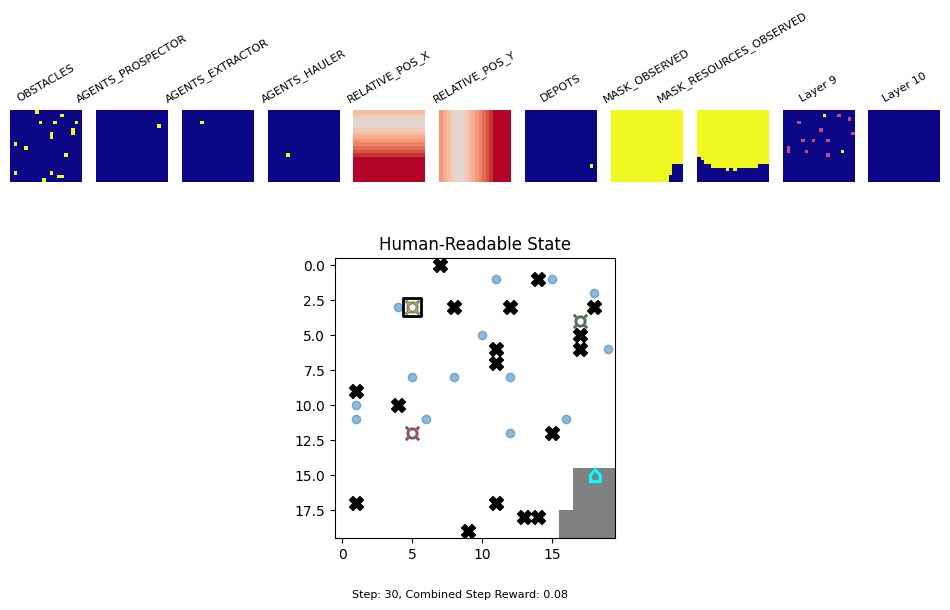

In [3]:
from isru_env import parallel_env, parallel_env_simple_obs, parallel_env_map_obs
from gymnasium.spaces import flatten
import numpy as np
from IPython.display import clear_output

env = parallel_env_map_obs(
    num_extractors=1,
    num_haulers=1,
    num_prospectors=1,
    num_obstacles=20,
    hauler_capacity=2.0,
    observation_radius=10,
    num_resources=20,
    observation_mask=True,
    world_size=20,
    render_mode="human",
)

env.reset()

# env.agents[1].cargo[env.possible_resources[0].resource_id] = 1.6
MAX_STEPS = 30
for step in range(MAX_STEPS):
    actions = {agent: flatten(env.action_space(agent), env.action_space(agent).sample()) for agent in env.possible_agents}
    obs, rewards, terminations, truncations, infos = env.step(actions)
    
    clear_output(wait=True)
    env.render_state(obs[env.agents[0]],figsize=(12, 6))
#         break
# obs, obs_mask = env.observe(env.agents[0])
# env.render_state(obs,figsize=(12, 6))

## Pickup/Drop

In [ ]:
from isru_env import parallel_env, parallel_env_simple_obs, parallel_env_map_obs
from gymnasium.spaces import flatten
import numpy as np

env = parallel_env_map_obs(
# env = parallel_env(
# env = parallel_env_simple_obs(
    num_extractors=1,
    num_haulers=1,
    num_prospectors=0,
    num_obstacles=0,
    observation_radius=1,
    num_resources=5,
    observation_mask=True,
    world_size=20,
    render_mode="human",
)

env.reset()

# Get agents.
extractor = env.agents[0]
hauler = env.agents[1]
# prospector = env.agents[2]

# Move extractor to resource location.
r = env.possible_resources[0]
extractor.position = np.argwhere(env.map_resources[r] > 0)[0]
print(f"Extractor moved to {extractor.position} (resource {r})")

# Move hauler next to the extractor.
hauler.position = extractor.position + np.array([0, 1])
print(f"Hauler moved to {hauler.position}")

env.render()

# Set up actions - extractor and hauler should both stay still, hauler should pick up.
actions = {
    extractor: flatten(env.action_space(extractor), {
        "movement": np.array([0, 0]),
        "communication": np.array([0]),
        "resources": np.array([0.0 for _ in env.possible_resources]),
    }),
    hauler: flatten(env.action_space(hauler), {
            "movement": np.array([0, 0]),
            "communication": np.array([0]),
            "resources": np.array([1.0 for _ in env.possible_resources]),
    })
}

env.step(actions)

env.render()

# Move the hauler to the depot.
depot = env.possible_depots[0]
hauler.position = depot.position
print(f"Hauler moved to depot at {depot.position}")

env.render()

# Set up actions - extractor and hauler should both stay still, hauler should drop off.
actions = {
    extractor: flatten(env.action_space(extractor), {
        "movement": np.array([0, 0]),
        "communication": np.array([0]),
        "resources": np.array([0.0 for _ in env.possible_resources]),
    }),
    hauler: flatten(env.action_space(hauler), {
            "movement": np.array([0, 0]),
            "communication": np.array([0]),
            "resources": np.array([-1.0 for _ in env.possible_resources]),
    })
}
env.step(actions)

env.render()

## Available Actions

In [ ]:
from isru_env import parallel_env, parallel_env_simple_obs
from gymnasium.spaces import flatten, unflatten
import numpy as np

env = parallel_env(
# env = parallel_env_simple_obs(
    num_extractors=1,
    num_haulers=1,
    num_prospectors=1,
    num_obstacles=0,
    observation_radius=10,
    hauler_capacity=1,
    observation_mask=True,
    world_size=5,
    render_mode="human",
    available_actions_mask=True,
)

env.reset()

# Get agents.
extractor = env.agents[0]
hauler = env.agents[1]
prospector = env.agents[2]

# Move extractor to center.
extractor.position = np.array([2.0, 2.0])
print(f"Extractor moved to {extractor.position}")

# Move hauler to bottom left corner.
hauler.position = np.array([0.0, 0.0])
print(f"Hauler moved to {hauler.position}")

# Move prospector to top right corner.
prospector.position = np.array([4.0, 4.0])
print(f"Prospector moved to {prospector.position}")

env.render()

# Print available actions.
def print_available_actions(agent):
    aa = env.available_actions(agent)
    aa_dict = unflatten(env.available_actions_space(agent), aa)
    print(f"Agent: {agent}, available actions:\n{aa_dict}")
for agent in env.agents:
    print_available_actions(agent)

## Map Generation

In [ ]:
from isru_env import parallel_env, parallel_env_simple_obs
from gymnasium.spaces import flatten, unflatten
import numpy as np

env = parallel_env(
    num_extractors=0,
    num_haulers=0,
    num_prospectors=1,
    num_obstacles=0,
    num_resources=1,
    observation_radius=10,
    hauler_capacity=1,
    world_size=2,
)

for i in range(100):
    env.reset()
    # Check that no resource is placed on top of the depot.
    depot = env.possible_depots[0]
    depot_pos = depot.position.astype(np.int32)
    for r in env.possible_resources:
        resource_pos = np.argwhere(env.map_resources[r] > 0)[0]
        assert not np.array_equal(depot_pos, resource_pos), f"{r} placed on top of depot at {depot_pos}"
    print(f"Reset {i}: Depot at {depot_pos}, Resource at {resource_pos}")
print("pass")


In [ ]:
from isru_env import parallel_env, parallel_env_simple_obs
from gymnasium.spaces import flatten, unflatten
import numpy as np

env = parallel_env_simple_obs(
    num_extractors=0,
    num_haulers=0,
    num_prospectors=1,
    num_obstacles=0,
    num_resources=0,
    observation_radius=10,
    hauler_capacity=1,
    world_size=2,
)

env.reset()
env.map_resources[env.possible_resources[0]][0, 1] = 1.0
env.agents[0].position = np.array([1.0, 0.0])
env.render()

## Observation Spaces

In [ ]:
from isru_env import parallel_env, parallel_env_simple_obs
from gymnasium.spaces import flatten, unflatten
import numpy as np

env = parallel_env(
    num_extractors=1,
    num_haulers=1,
    num_prospectors=1,
    num_obstacles=0,
    num_resources=0,
    observation_radius=10,
    hauler_capacity=1,
    world_size=2,
)

env.reset()

for a in env.agents:
    space = env.observation_space(a)
    assert list(space["agents"].keys())[0] == a, f"Observation space order is incorrect for agent {a}. Actual order: {list(space['agents'].keys())}"
    obs, _ = env.observe(a)
    assert list(obs["agents"].keys())[0] == a, f"Observation order is incorrect for agent {a}. Actual order: {list(obs['agents'].keys())}"
print("pass")

Font 'rm' does not have a glyph for '\U0001f50d' [U+1f50d], substituting with a dummy symbol.


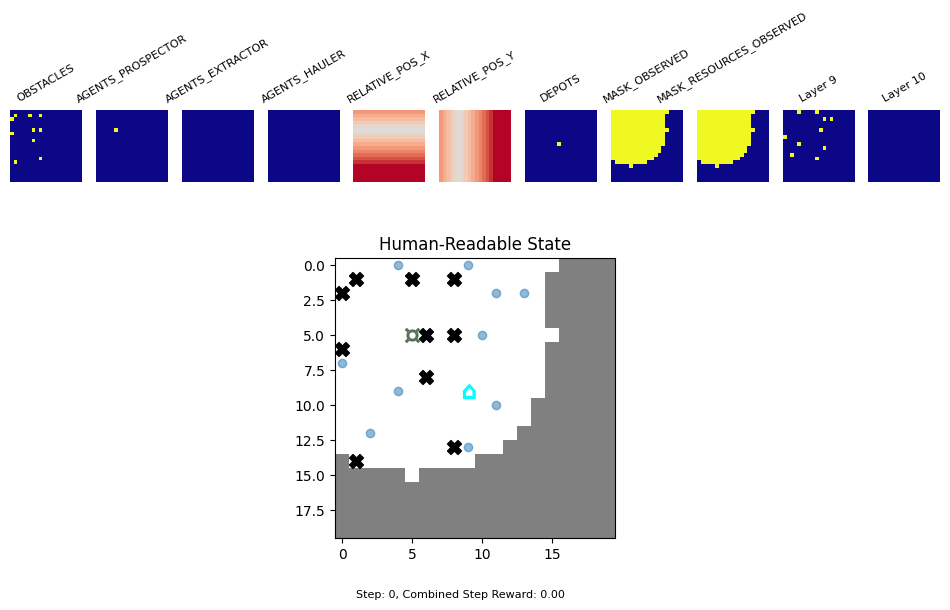

In [1]:
from isru_env import   parallel_env_map_obs
from gymnasium.spaces import flatten
import numpy as np
from IPython.display import clear_output

env = parallel_env_map_obs(
    num_extractors=0,
    num_haulers=0,
    num_prospectors=1,
    num_obstacles=20,
    hauler_capacity=2.0,
    observation_radius=10,
    num_resources=20,
    observation_mask=True,
    world_size=20,
    render_mode="human",
)

env.reset()

# Move agent 0 to the center.
env.possible_agents[0].position = np.array([5.0, 5.0])

env.render_state(env.observe(env.possible_agents[0])[0], figsize=(12, 6))